# DS105 Final Project
## Time-Based Browsing Pattern Analyzer with Deep Learning & RAM Correlation

This notebook walks through the full pipeline step by step with explanations.


## Step 0: Setup

In [1]:
import sys, os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
print('Setup complete!')

Setup complete!


## Step 1: Generate Sample Data

In [2]:
os.chdir('..')  # Go to project root
from collect.generate_sample import generate_browsing_history, generate_ram_log, generate_domain_category_map

browsing = generate_browsing_history(days=5)
ram = generate_ram_log(days=5)
domain_map = generate_domain_category_map()

print(browsing.head())

Generating 5 days of browsing history...
  ✅ Saved 651 records to data/browsing_history.csv
Generating RAM log...
  ✅ Saved 43201 RAM records to data/ram_log.csv
Generating domain-category map...
  ✅ Saved 25 entries to data/domain_category_map.csv
             timestamp        domain      category                 title  \
0  2026-03-01T00:35:10  facebook.com        social  Page on facebook.com   
1  2026-03-01T07:13:59  linkedin.com  professional  Page on linkedin.com   
2  2026-03-01T07:48:46      ndtv.com          news      Page on ndtv.com   
3  2026-03-01T07:55:38     gmail.com         email     Page on gmail.com   
4  2026-03-01T08:01:37  linkedin.com  professional  Page on linkedin.com   

   hour        date day_name  
0     0  2026-03-01   Sunday  
1     7  2026-03-01   Sunday  
2     7  2026-03-01   Sunday  
3     7  2026-03-01   Sunday  
4     8  2026-03-01   Sunday  


## Step 2: Preprocess

In [3]:
from prep.preprocess import preprocess

df = preprocess(
    input_path='data/browsing_history.csv',
    output_path='data/browsing_history.csv',
    map_path='data/domain_category_map.csv'
)

print('Category distribution:')
print(df['category'].value_counts())

Preprocessing browsing history...
  Loaded 651 records
  ✅ Saved 651 clean records → data/browsing_history.csv
  Categories found: ['social', 'professional', 'news', 'email', 'learning', 'search', 'ai_tools', 'video', 'messaging', 'shopping']
Category distribution:
category
learning        166
social          105
ai_tools         63
messaging        58
email            55
search           53
news             42
shopping         41
professional     37
video            31
Name: count, dtype: int64


## Step 3: Exploratory Data Analysis

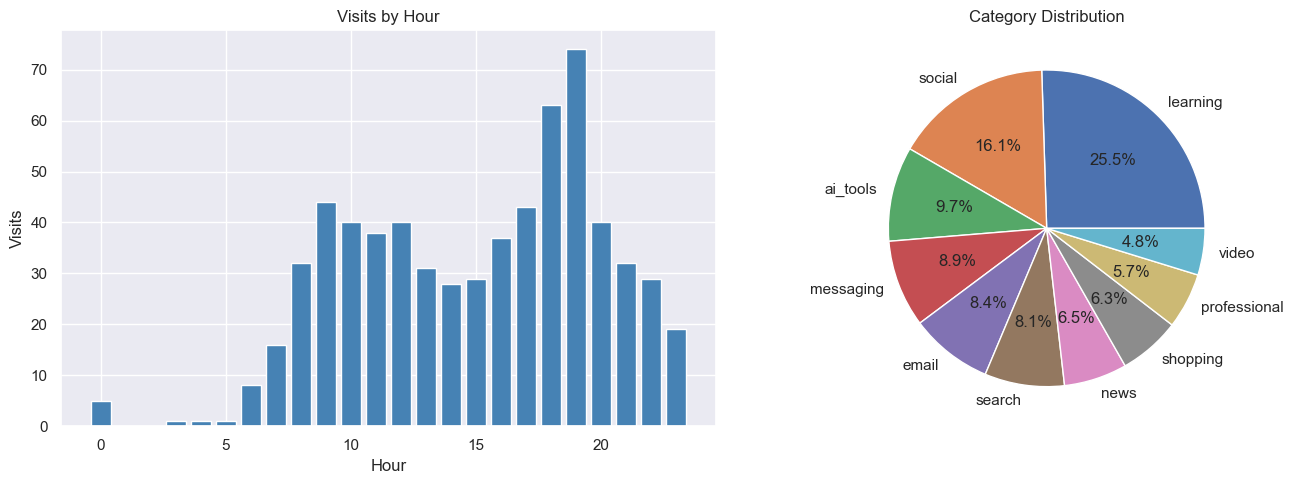

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly activity
hourly = df.groupby('hour')['domain'].count()
axes[0].bar(hourly.index, hourly.values, color='steelblue')
axes[0].set_title('Visits by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Visits')

# Category pie
cat_counts = df['category'].value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%')
axes[1].set_title('Category Distribution')

plt.tight_layout()
plt.show()

## Step 4: Sessionization

In [5]:
from prep.sessionize import sessionize

sessions = sessionize(
    input_path='data/browsing_history.csv',
    output_path='data/sessions.csv',
    gap_minutes=15
)

print(f'Total sessions: {len(sessions)}')
print(sessions[['session_id','duration_min','top_category','social_ratio']].head(10))

Sessionizing (gap = 15 min)...
  Total events: 651
  Total sessions: 118
  ✅ Saved 118 sessions → data/sessions.csv
  Avg session duration: 22.4 min
  Top category overall: learning
Total sessions: 118
   session_id  duration_min  top_category  social_ratio
0           0      1.000000        social      1.000000
1           1      1.000000  professional      0.000000
2           2     39.350000      learning      0.000000
3           3     70.416667      learning      0.166667
4           4     56.683333      ai_tools      0.200000
5           5     19.466667      learning      0.000000
6           6      1.083333      ai_tools      0.000000
7           7     50.300000      learning      0.090909
8           8      1.000000        social      1.000000
9           9      3.066667      ai_tools      0.000000


## Step 5: RAM Correlation

In [6]:
from analytics.ram_correlation import merge_ram

merged, ram_by_cat, ram_by_hour = merge_ram(
    browsing_path='data/browsing_history.csv',
    ram_path='data/ram_log.csv',
    output_path='data/merged_browsing_ram.csv'
)

print('RAM by category:')
print(ram_by_cat)

Merging browsing data with RAM logs...
  Merged 651 records

  📊 RAM by Category (Top 5):
           mean_browser_ram_mb  peak_browser_ram_mb  mean_system_ram_mb  \
category                                                                  
social                   980.7               1424.9              7357.5   
learning                 977.7               1375.4              7288.0   
messaging               1002.0               1356.7              7514.4   
shopping                 948.9               1344.2              7102.2   
news                     945.5               1326.0              7026.6   

           mean_cpu_percent  visit_count  
category                                  
social                 55.7          105  
learning               53.3          166  
messaging              50.3           58  
shopping               57.2           41  
news                   46.9           42  

  🔴 Top 3 memory-heavy categories: ['social', 'learning', 'messaging']
  ✅ Saved m

## Step 6: Clustering

In [7]:
from models.clustering import run_clustering

sessions_clust, score, profiles = run_clustering(
    sessions_path='data/sessions.csv',
    output_path='data/sessions_clustered.csv',
    n_clusters=4
)

print(f'Silhouette Score: {score:.4f}')
print(sessions_clust['cluster_label'].value_counts())

Running KMEANS clustering (k=4)...
  Silhouette Score: 0.2228  (higher is better, >0.3 is good)

  Cluster Profiles:
         duration_min  total_visits  unique_domains  social_ratio  video_ratio  learning_ratio  shopping_ratio  ai_tools_ratio  switching_rate    hour
cluster                                                                                                                                               
0              60.247        13.367           9.900         0.160        0.046           0.248           0.038            0.10           0.905  14.733
1               7.222         1.900           1.800         0.925        0.000           0.000           0.000            0.00           0.233  15.400
2               2.716         1.273           1.182         0.000        0.000           0.545           0.000            0.00           0.076  11.955
3              12.586         3.625           3.429         0.112        0.037           0.218           0.162            0.17  

## Step 7: Autoencoder Anomaly Detection

In [8]:
from models.autoencoder import run_autoencoder

sessions_final, errors, threshold = run_autoencoder(
    sessions_path='data/sessions_clustered.csv',
    output_path='data/sessions_clustered.csv',
    epochs=30,
    anomaly_percentile=95
)

print(f'Anomalies detected: {sessions_final["is_anomaly"].sum()}')

Running Autoencoder Anomaly Detection...
  Building autoencoder (input_dim=9, encoding_dim=5)
  Final validation loss: 0.7021
  Threshold (p95): 1.9946
  Anomalous sessions detected: 6

  Top 5 Anomalous Sessions:
 session_id          start_time  hour  duration_min top_category  social_ratio  switching_rate  reconstruction_error
        113 2026-03-05 21:42:07    21      4.483333        video           0.0            0.75              3.479420
         19 2026-03-02 00:09:15     0      3.633333       social           0.5            1.00              3.357832
         45 2026-03-03 00:18:43     0      1.000000     shopping           0.0            0.00              2.956163
         47 2026-03-03 03:04:28     3      1.000000     shopping           0.0            0.00              2.680416
         96 2026-03-05 08:01:05     8      1.000000     shopping           0.0            0.00              2.349879

  Anomaly Explanations:
    → Session 113: very high tab switching
    → Session 19

## Step 8: Recommendations

In [9]:
from analytics.recommendations import generate_recommendations

recs = generate_recommendations(
    sessions_path='data/sessions_clustered.csv',
    ram_by_cat_path='data/ram_by_category.csv'
)

Generating recommendations...

  📋 7 Recommendations Generated:

  1. 🌙 [Digital Wellbeing] Late-Night Social Media Loop Detected
     Evidence: 42% of late-night sessions are social media
     Action:   Set a screen-off rule after 10 PM. Use 'Do Not Disturb' or app timers.

  2. ⏰ [Productivity] Peak Distraction Hour: 18:00
     Evidence: Highest browsing volume at 18:00 with 78 visits
     Action:   Protect 18:00–19:00 for deep work. Turn off notifications, close non-essential tabs.

  3. 📚 [Positive Habit] Strong Learning Behavior Detected
     Evidence: Learning sites account for 27% of browsing
     Action:   Great job! Consider scheduling your learning sessions in the morning when focus is highest, and tracking progress with Notion or Obsidian.

  4. 🔄 [Focus] High Tab-Switching Detected
     Evidence: Average category switching rate: 0.67 (>0.55 = fragmented)
     Action:   Try single-tab browsing for focused tasks. OneTab or Tab Suspender extensions can help reduce tab overload

## Step 9: Visualizations

In [10]:
from analytics.visualizations import run_all_visualizations
run_all_visualizations()
print('All figures saved to reports/figures/')

Generating all visualizations...
  Saved: reports/figures/01_hourly_activity.png
  Saved: reports/figures/02_category_distribution.png


d:\Guvi\Time Based Browsing Pattern Analyzer\notebooks\../src\analytics\visualizations.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, ax=ax, palette="Blues_r")


  Saved: reports/figures/03_top_domains.png
  Saved: reports/figures/04_daily_category_stack.png
  Saved: reports/figures/05_day_hour_heatmap.png
  Saved: reports/figures/06_cluster_analysis.png
  Saved: reports/figures/08_anomaly_detection.png
  Saved: reports/figures/07_ram_by_category.png

  ✅ All figures saved to reports/figures/
All figures saved to reports/figures/


## Done! Generate Final Report

In [11]:
from analytics.report_generator import generate_report
generate_report()
print('Report saved to reports/final_report.md')

Generating final report...
  ✅ Report saved → reports/final_report.md
Report saved to reports/final_report.md
